In [26]:
import numpy as np
import matplotlib
import pandas as pd

In [27]:
dataset = pd.read_csv('/Users/eddie/Downloads/lake_erie_habs_W4_6_8_9_12_13_16_2013-2020.csv')

In [28]:
print(dataset)

          Date  Latitude   Longitude   Secchi Depth   CTD Temperature  \
0    5/29/2013    41.7134    -83.3804            1.6             18.5   
1    5/29/2013    41.8343    -83.3633            1.0             20.3   
2    5/29/2013    41.8267    -83.1930            1.5             19.8   
3    6/10/2013    41.7144    -83.3805            0.5             20.7   
4    6/10/2013    41.8353    -83.3631            0.7             23.5   
..         ...        ...         ...            ...              ...   
834  10/5/2020    41.7176    -83.4239            0.8             14.4   
835  10/5/2020    41.6599    -83.1468            1.8             15.4   
836  10/5/2020    41.7436    -83.1526            1.8             15.7   
837  10/5/2020    41.7040    -83.2552            1.0             15.2   
838  10/5/2020    41.8267    -83.1947            3.5             15.7   

     CTD Specific Conductivity   CTD Dissolved Oxygen   Turbidity   \
0                         391.3                   7.6

In [29]:
train = dataset.iloc[:743,:]
test = dataset.iloc[743:,:]
print(train)
print(test)
X_train = pd.DataFrame(train.iloc[:,4:15].values)
Y_train = train.iloc[:,16:].values
print(X_train.shape)
print(Y_train.shape)
X_test = pd.DataFrame(test.iloc[:,4:15].values)
X_test_shap = pd.DataFrame(test.iloc[:,4:15])
Y_test = test.iloc[:,16:].values
print(X_test.shape)
print(Y_test.shape)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


          Date  Latitude   Longitude   Secchi Depth   CTD Temperature  \
0    5/29/2013    41.7134    -83.3804           1.60             18.5   
1    5/29/2013    41.8343    -83.3633           1.00             20.3   
2    5/29/2013    41.8267    -83.1930           1.50             19.8   
3    6/10/2013    41.7144    -83.3805           0.50             20.7   
4    6/10/2013    41.8353    -83.3631           0.70             23.5   
..         ...        ...         ...            ...              ...   
738  10/7/2019    41.6599    -83.1467           1.00             18.2   
739  10/7/2019    41.7428    -83.1354           1.25             18.2   
740  10/7/2019    41.7023    -83.2639           1.25             18.5   
741  10/7/2019    41.8270    -83.1949           1.50             17.2   
742  6/16/2020    41.7054    -83.3864           0.20             20.3   

     CTD Specific Conductivity   CTD Dissolved Oxygen   Turbidity   \
0                         391.3                   7.6

In [30]:
import tensorflow as tf

In [31]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from numpy import absolute
from numpy import mean
from numpy import std

In [32]:
model = Lasso(alpha=0.01)

In [33]:
model.fit(X_train_scaled,Y_train)

c:\Users\eddie\anaconda3\envs\SSTP-Injury\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.855e+03, tolerance: 2.113e+02
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.01)

In [34]:
res = model.predict(X_test_scaled)
print(res)

[-39.35062263   0.89512522 -11.38751437  38.9221217   39.45309052
  49.4149689   35.64242588  30.53025877  28.50253347  54.55020661
  21.64290943  43.97380645  22.48065932  38.83900701  26.09614547
  52.56985825  27.04791415  48.08430757  33.91348868  37.21473942
  25.01571765  50.67601026  18.81269988  25.16369225  23.29248569
  27.82348324  53.48821476  31.69975487  50.64690955  29.98496752
  31.46199141  42.06364485  22.62911413  58.48704338  36.47925713
  57.37144283  37.79611984  44.02826533  41.64457701  23.4935286
  46.17037472  33.80159532  72.86404991  34.83286429  32.05470114
  37.17350118  23.68240546  36.41048834  37.11152648  55.77309728
  23.27108164  21.79131593  21.43952505  22.33878031  34.15619689
  35.34176215  58.46443669  33.86483814  25.71489684  36.20243104
  22.71913937  41.12857516  23.37802165  49.54369425  27.11219511
  24.46622949  30.88331321  20.01238709  35.81442162  38.23188488
  41.34045001  23.96208294  23.58730926  31.21093721  17.47404606
  45.352017

In [35]:
from sklearn.metrics import r2_score 
r2 = r2_score(Y_test, res) 
print(r2)

0.1561826320020463


In [36]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(Y_test,res)
print(mae)

13.733700496406817


In [37]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(Y_test,res)
print(mape)

1.5577647942561292


In [38]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(Y_test,res)
print(rmse)

16.81429371017692


In [39]:
features = pd.DataFrame(dataset.iloc[:,4:15])
features = features.columns
print(features)

Index(['CTD Temperature', 'CTD Specific Conductivity ',
       'CTD Dissolved Oxygen ', 'Turbidity ', 'Total Phosphorus',
       'Total Dissolved Phosphorus ', 'Ammonia', 'Nitrate + Nitrite ',
       'Particulate Organic Carbon ', 'Particulate Organic Nitrogen ',
       'Total Suspended Solids'],
      dtype='object')


In [40]:
import shap

In [41]:
print(X_test)

      0      1     2      3      4      5      6      7     8     9     10
0   20.6  309.0  7.68  57.20  22.70   7.86  36.56  0.707  0.56  0.15  2.24
1   21.7  442.4  7.02  41.30  52.74  13.00  59.00  0.701  1.97  0.42  8.00
2   20.2  259.3  7.69  35.80  90.23  25.36  45.80  1.870  0.58  0.07  9.48
3   24.9  353.0  8.68   6.80  31.78   7.23  28.74  0.914  0.52  0.11  5.48
4   24.3  301.0  9.64   5.38  26.70   8.87  44.73  0.807  0.66  0.15  2.47
..   ...    ...   ...    ...    ...    ...    ...    ...   ...   ...   ...
91  14.4  313.1  9.00   9.38  47.68  18.77  20.71  0.069  0.98  0.17  9.56
92  15.4  249.6  8.90   3.48  22.20   8.86  20.53  0.105  0.46  0.09  6.13
93  15.7  221.3  8.97   2.30  14.30   5.21  12.07  0.249  0.27  0.04  3.56
94  15.2  258.4  9.07   7.24  28.96   9.31   2.89  0.002  0.83  0.09  8.39
95  15.7  226.4  8.54   1.27  13.01   5.44  23.46  0.271  0.19  0.02  1.76

[96 rows x 11 columns]


In [42]:
explainer = shap.LinearExplainer(model, X_train)
values = explainer.shap_values(X_test_shap)
shap_values = explainer(X_test_shap)


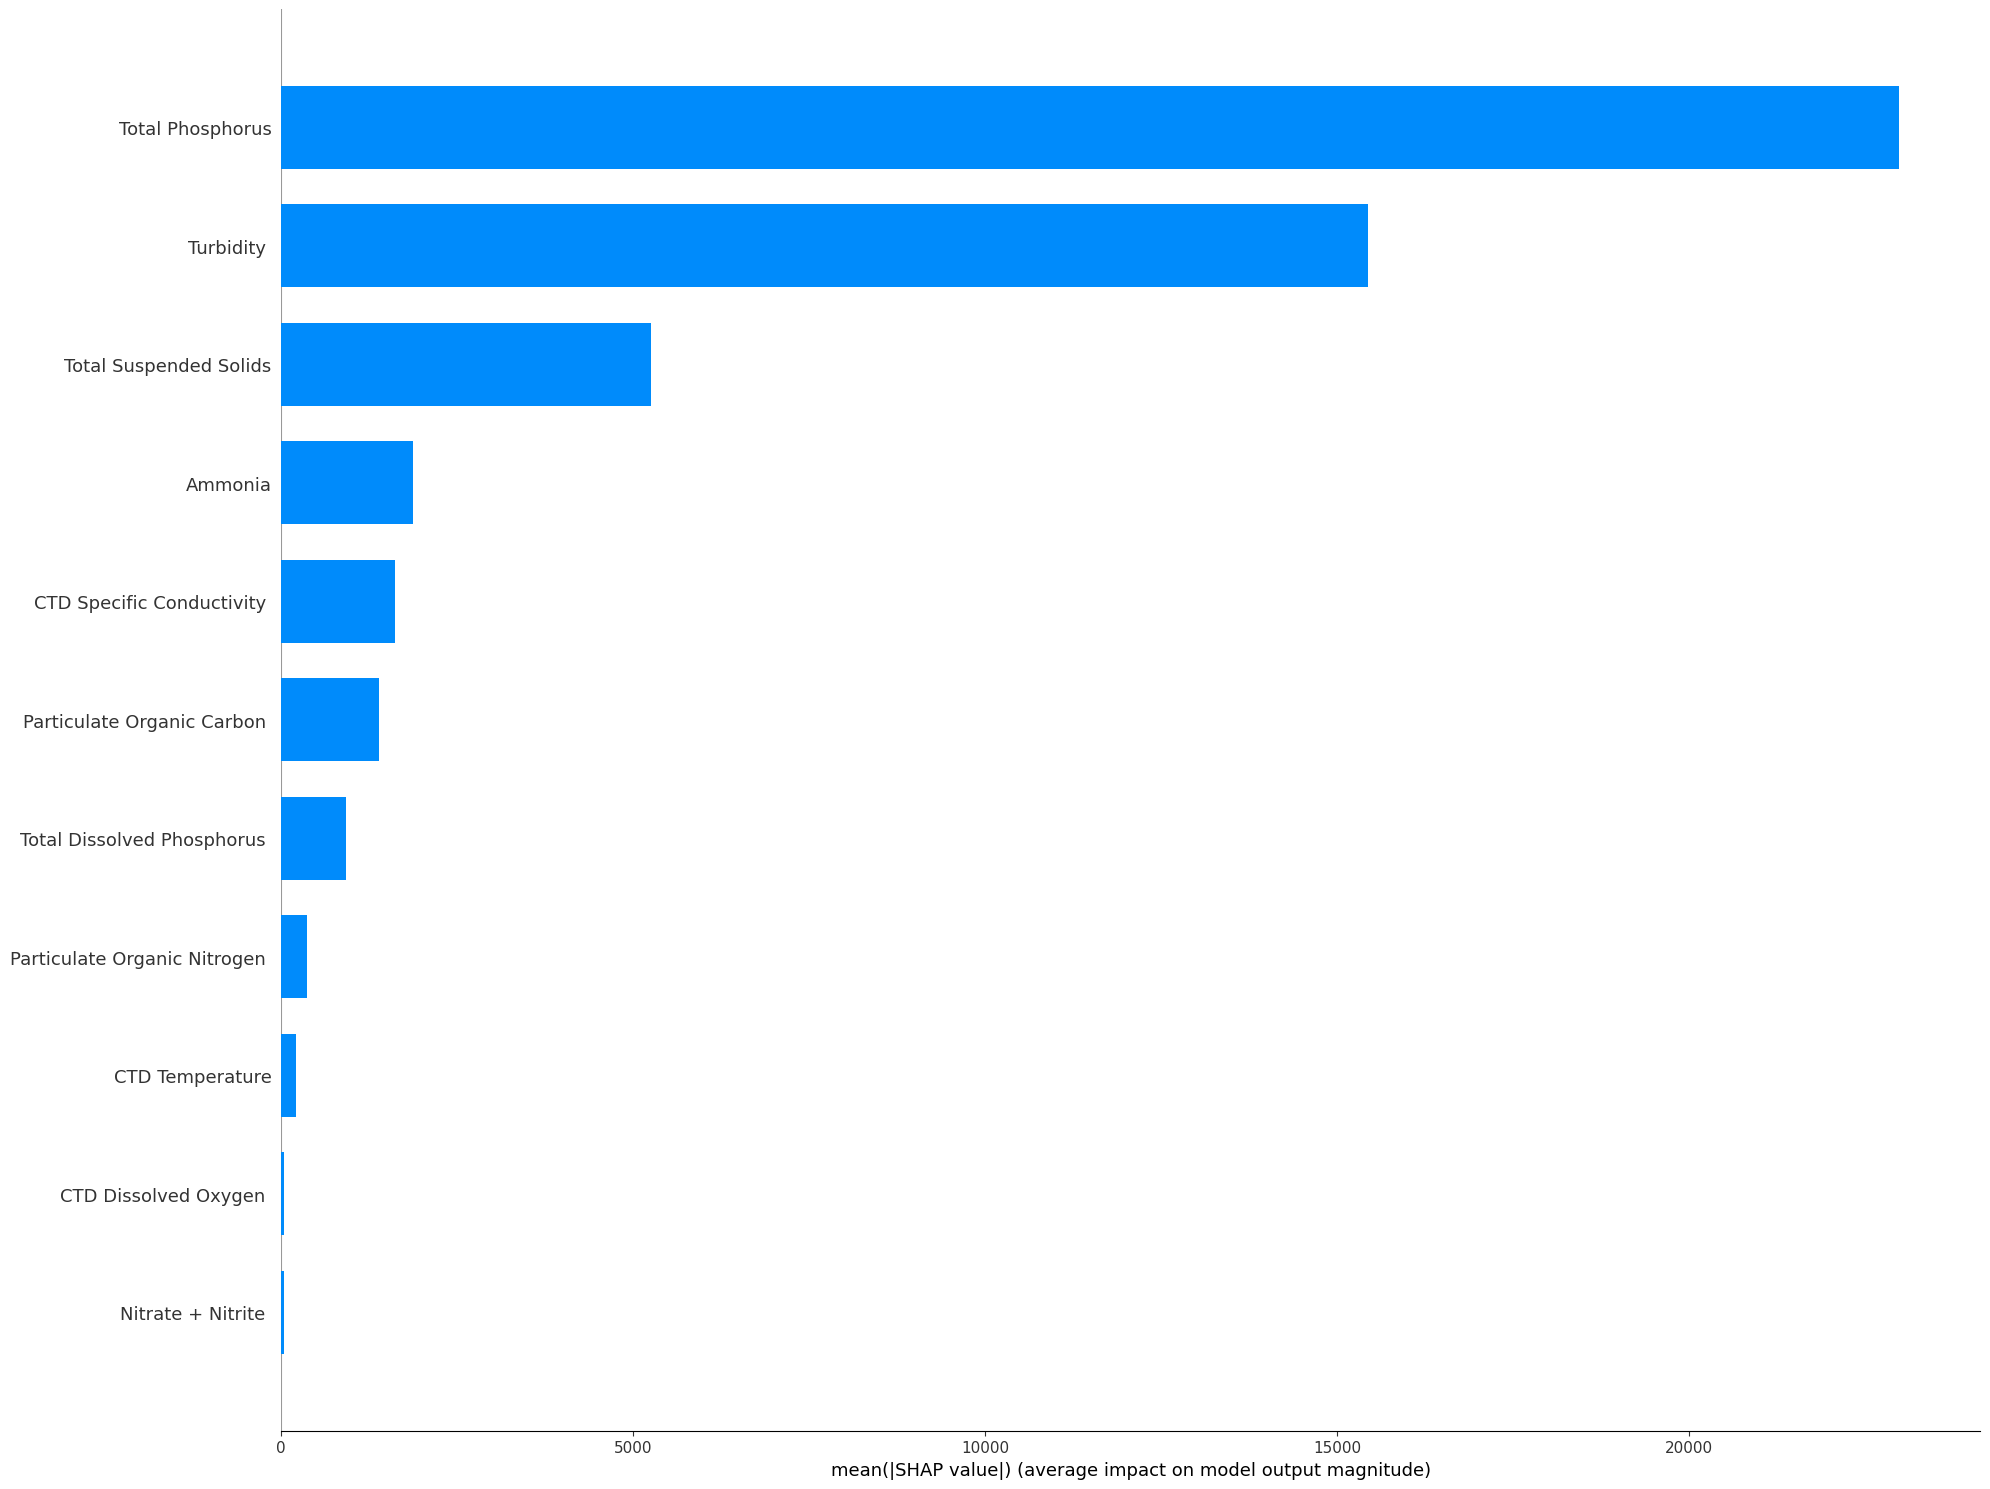

In [43]:
shap.summary_plot(values, X_test,feature_names = features,plot_type="bar",plot_size = (20,15),show=False)

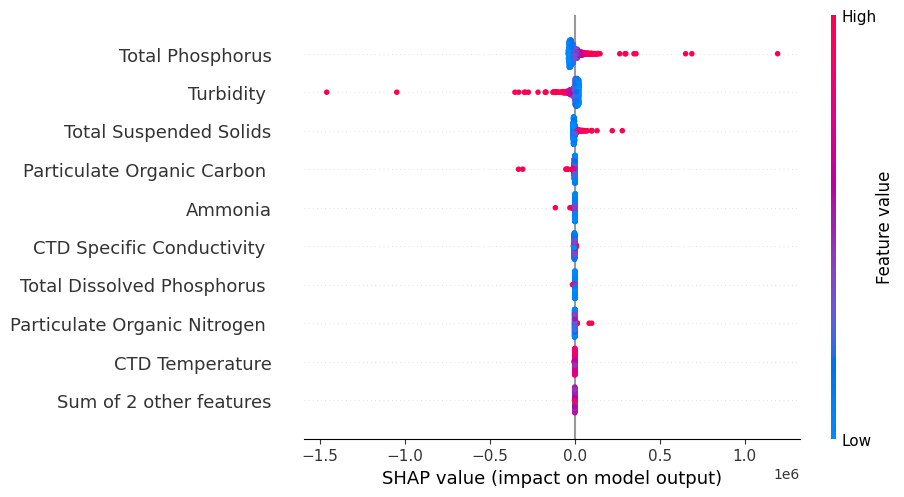

In [44]:
X_test_shap = pd.DataFrame(train.iloc[:,4:15])
shap_values = explainer(X_test_shap)
shap.plots.beeswarm(shap_values=shap_values)

In [45]:
import matplotlib.pyplot as plt

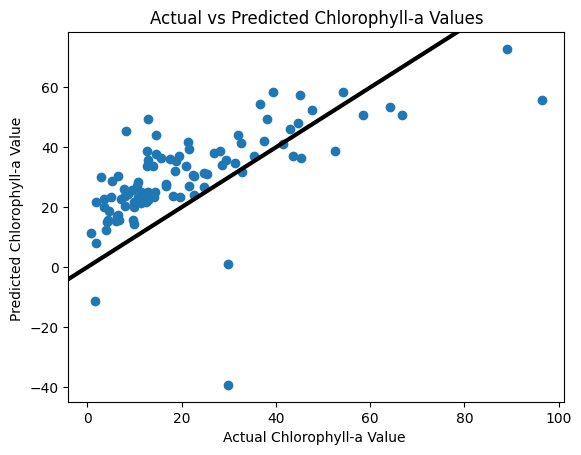

In [46]:
plt.scatter(Y_test, res)
plt.xlabel('Actual Chlorophyll-a Value ')
plt.ylabel('Predicted Chlorophyll-a Value ')
plt.title('Actual vs Predicted Chlorophyll-a Values')
xpoints = ypoints = plt.xlim()
plt.plot(xpoints, ypoints, linestyle='-', color='k', lw=3, scalex=False, scaley=False)
plt.show()